# Exercise 2: Exploratory Data Analysis (EDA) — PCL Detection

This notebook performs two distinct EDA techniques on the **Don't Patronize Me** dataset (SemEval 2022 Task 4, Subtask 1: Binary Classification).

**Technique 1:** Basic Statistical Profiling (class distribution, token length analysis)  
**Technique 2:** Lexical Analysis (n-gram comparison, word clouds per class)

Each technique includes:
- Visual/tabular evidence
- Analysis of findings
- Impact statement on the PCL classification approach

In [1]:
# ============================================================
# Cell 1: Setup & Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Optional: install wordcloud if not present
# !pip install wordcloud
from wordcloud import WordCloud

# Optional: install nltk if not present
# !pip install nltk
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

In [2]:
# ============================================================
# Cell 2: Load Dataset
# ============================================================
# Adjust these paths to match your local setup.
# The main dataset file is a TSV with columns:
#   par_id, art_id, keyword, country_code, text, label
from dont_patronize_me import DontPatronizeMe

dpm = DontPatronizeMe(train_path='.', test_path='test/task4_test.tsv')
dpm.load_task1()
df = dpm.train_task1_df
df

,par_id,art_id,keyword,country,text,label,orig_label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0,0
...,...,...,...,...,...,...,...
10464,10465,@@14297363,women,lk,"""Sri Lankan norms and culture inhibit women fr...",0,1
10465,10466,@@70091353,vulnerable,ph,He added that the AFP will continue to bank on...,0,0
10466,10467,@@20282330,in-need,ng,""""""" She has one huge platform , and informatio...",1,3
10467,10468,@@16753236,hopeless,in,""""""" Anja Ringgren Loven I ca n't find a word t...",1,4


In [3]:
# ============================================================
# Cell 3: Quick sanity checks
# ============================================================
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated(subset='text').sum()}")
print(f"Unique paragraphs: {df['par_id'].nunique()}")
print(f"\nOriginal label distribution:\n{df['label'].value_counts().sort_index()}")

Missing values per column:
par_id        0
art_id        0
keyword       0
country       0
text          0
label         0
orig_label    0
dtype: int64

Duplicate rows: 0
Unique paragraphs: 10469

Original label distribution:
label
0    9476
1     993
Name: count, dtype: int64


---
## Basic Statistical Profiling

We examine **vocabulary size**, **class distribution** and **token length distributions** across the two classes to understand the structural properties of the dataset.

     Class  Count  Percentage (%)
No PCL (0)   9476            90.5
   PCL (1)    993             9.5


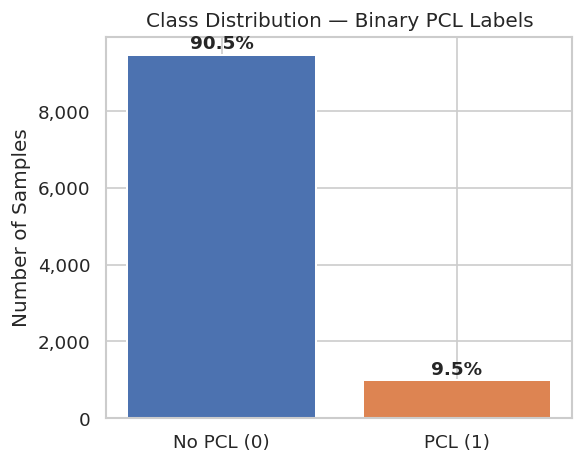

In [ ]:
# ============================================================
# Cell 4: Class Distribution
# ============================================================
label_counts = df['label'].value_counts().sort_index()
label_pcts = df['label'].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    'Class': ['No PCL (0)', 'PCL (1)'],
    'Count': label_counts.values,
    'Percentage (%)': label_pcts.values.round(1)
})
print(class_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4C72B0', '#DD8452']
bars = ax.bar(['No PCL (0)', 'PCL (1)'], label_counts.values, color=colors,
              edgecolor='white', linewidth=1.2)

for bar, pct in zip(bars, label_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution — Binary PCL Labels')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.savefig('eda_diagrams/fig_class_distribution.png', bbox_inches='tight')
plt.show()

In [5]:
# ============================================================
# Cell 5: Token Length Analysis
# ============================================================
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['char_count'] = df['text'].astype(str).apply(len)

# Summary statistics per class
length_stats = df.groupby('label')['word_count'].describe().round(1)
length_stats.index = ['No PCL (0)', 'PCL (1)']
print("Token (word) count statistics per class:")
print(length_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

Token (word) count statistics per class:
             count  mean   std  min   25%   50%   75%    max
No PCL (0)  9476.0  47.9  28.6  0.0  30.0  42.0  59.0  909.0
PCL (1)      993.0  53.6  32.8  6.0  33.0  47.0  67.0  512.0


In [6]:
# ============================================================
# Cell 6: Vocabulary Size (Unique Words)
# ============================================================
all_words = df['text'].astype(str).str.lower().str.findall(r"\b\w+\b")
vocab = set(word for words in all_words for word in words)
print(f"Vocabulary size (unique words): {len(vocab):,}")

Vocabulary size (unique words): 30,037


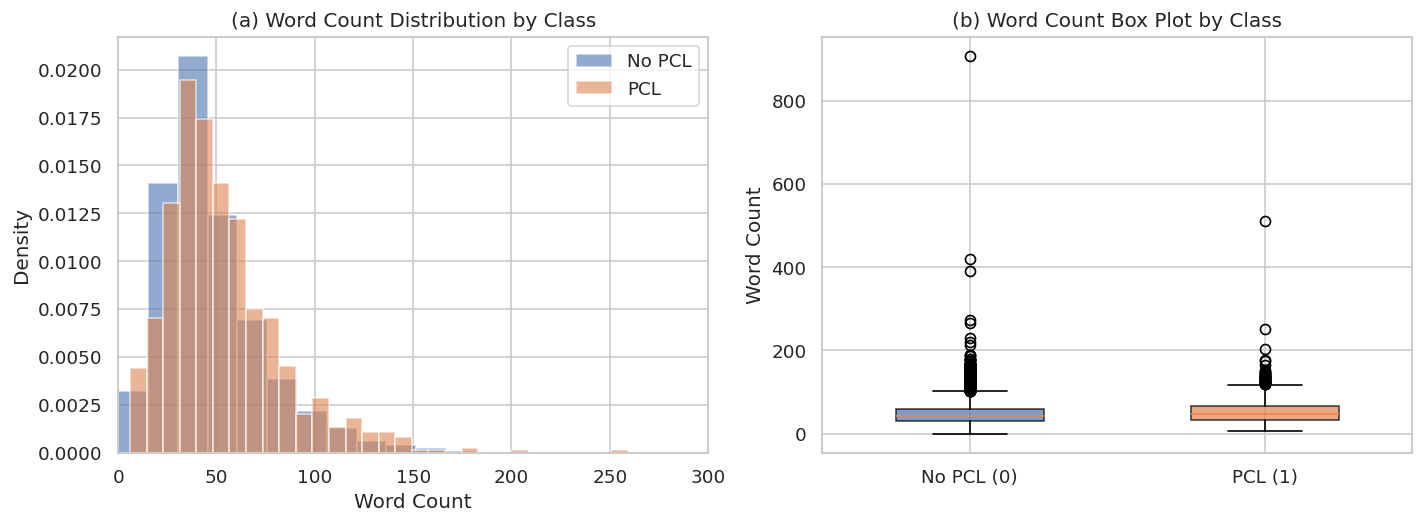

max_length=128 tokens (~98 words): 5.6% of samples would be truncated
max_length=200 tokens (~153 words): 0.6% of samples would be truncated
max_length=256 tokens (~196 words): 0.1% of samples would be truncated
max_length=512 tokens (~393 words): 0.0% of samples would be truncated


In [ ]:
# ============================================================
# Cell 7: Token Length Distribution Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Overlapping histograms
for label, color, name in [(0, '#4C72B0', 'No PCL'), (1, '#DD8452', 'PCL')]:
    subset = df[df['label'] == label]['word_count']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=name, density=True)

axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Density')
axes[0].set_title('(a) Word Count Distribution by Class')
axes[0].legend()
axes[0].set_xlim(0, 300)

# (b) Box plot
box_data = [df[df['label'] == 0]['word_count'],
            df[df['label'] == 1]['word_count']]
bp = axes[1].boxplot(box_data, labels=['No PCL (0)', 'PCL (1)'], patch_artist=True,
                     widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Word Count')
axes[1].set_title('(b) Word Count Box Plot by Class')

plt.tight_layout()
plt.savefig('eda_diagrams/fig_token_length.png', bbox_inches='tight')
plt.show()

# What percentage of samples exceed common max_length thresholds?
for threshold in [128, 200, 256, 512]:
    # Rough token-to-word ratio for BERT tokenizers is ~1.3
    word_equiv = int(threshold / 1.3)
    pct_over = (df['word_count'] > word_equiv).mean() * 100
    print(f"max_length={threshold} tokens (~{word_equiv} words): {pct_over:.1f}% of samples would be truncated")

### Analysis

**Findings:**
1. **Severe class imbalance:** The PCL class (label 1) makes up roughly ~9.5% of the dataset, while No PCL (label 0) accounts for ~90.5%. This is a heavily imbalanced binary classification problem.
2. **Token lengths:** PCL paragraphs tend to be slightly longer on average than No PCL paragraphs. The bulk of samples fall within 20–80 words.
3. **Truncation risk:** Very few samples exceed 256 tokens, suggesting `max_length=256` is a reasonable setting that avoids significant information loss.

### Impact Statement

- **Class imbalance** means standard accuracy is a misleading metric — a model predicting all-0 would achieve ~90% accuracy. F1-score of the positive class is the correct evaluation metric. Training must address this imbalance through **oversampling the minority class**, **weighted loss functions**, or a **weighted random sampler**.
- **Data augmentation** (synonym replacement, back-translation, paraphrasing) should be applied specifically to the PCL minority class to expand it.
- The token length analysis justifies setting **`max_length=256`** for the transformer tokenizer, which balances capturing the full context against computational efficiency.

---
## Lexical Analysis (N-gram Comparison & Word Clouds)

We compare the most frequent bigrams and trigrams in PCL vs. No PCL paragraphs, and visualise the results with word clouds to identify linguistically discriminative patterns.

In [8]:
# ============================================================
# Cell 8: Text Preprocessing for Lexical Analysis
# ============================================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Lowercase, remove HTML tags, non-alpha chars, and stopwords."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)           # HTML tags
    text = re.sub(r'[^a-z\s]', '', text)          # non-alpha
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df['clean_tokens'] = df['text'].apply(clean_text)

pcl_tokens = df[df['label'] == 1]['clean_tokens']
no_pcl_tokens = df[df['label'] == 0]['clean_tokens']

In [9]:
# ============================================================
# Cell 8b: Stop Word Density (Filler Ratio)
# ============================================================
def stopword_density(text):
    tokens = [t for t in word_tokenize(str(text).lower()) if t.isalpha()]
    if not tokens:
        return 0.0
    stop_count = sum(t in stop_words for t in tokens)
    return stop_count / len(tokens)

df['stopword_density'] = df['text'].apply(stopword_density)

overall_density = df['stopword_density'].mean() * 100
density_by_class = (
    df.groupby('label')['stopword_density']
      .mean()
      .rename(index={0: 'No PCL (0)', 1: 'PCL (1)'})
      .mul(100)
      .round(2)
)

print(f"Overall stop-word density: {overall_density:.2f}%")
print("\nStop-word density by class (%):")
print(density_by_class.to_string())

if overall_density >= 50:
    print("\nInterpretation: High filler density; consider more aggressive cleaning.")
else:
    print("\nInterpretation: Moderate filler density; standard stop-word cleaning is likely sufficient.")

Overall stop-word density: 42.72%

Stop-word density by class (%):
label
No PCL (0)    42.45
PCL (1)       45.32

Interpretation: Moderate filler density; standard stop-word cleaning is likely sufficient.


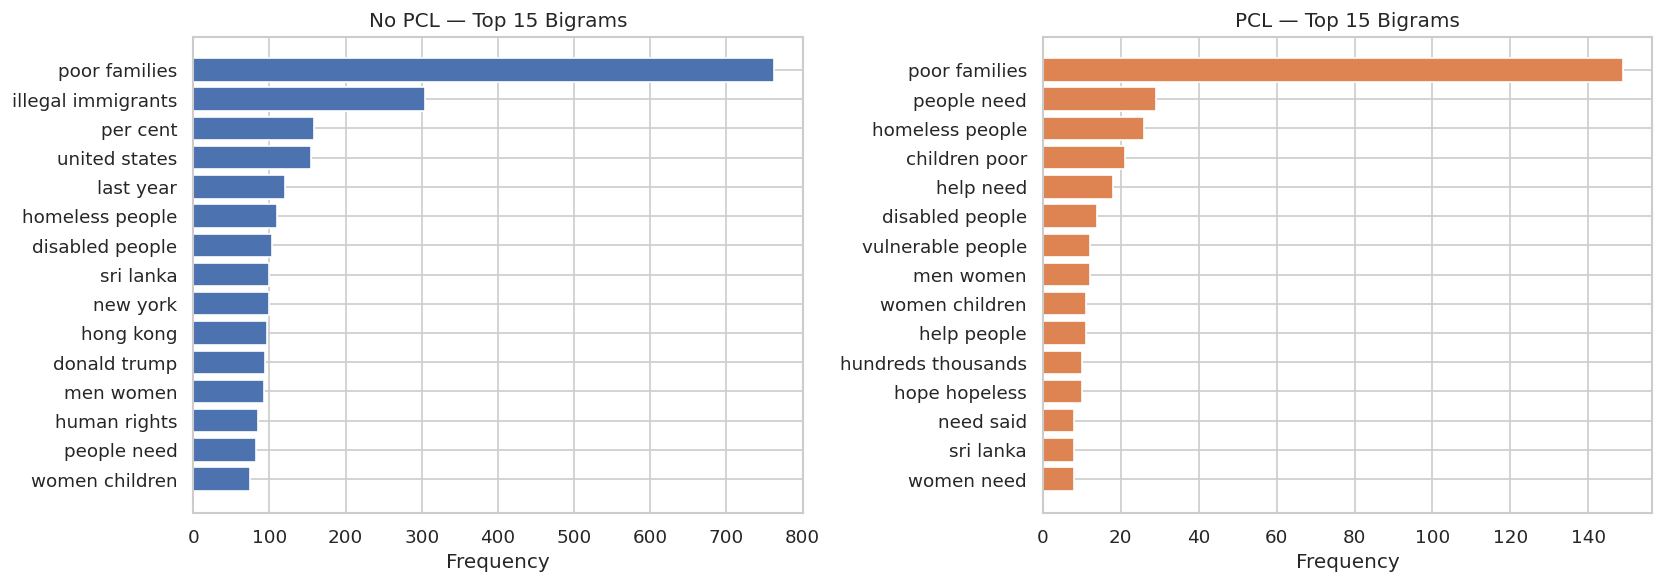

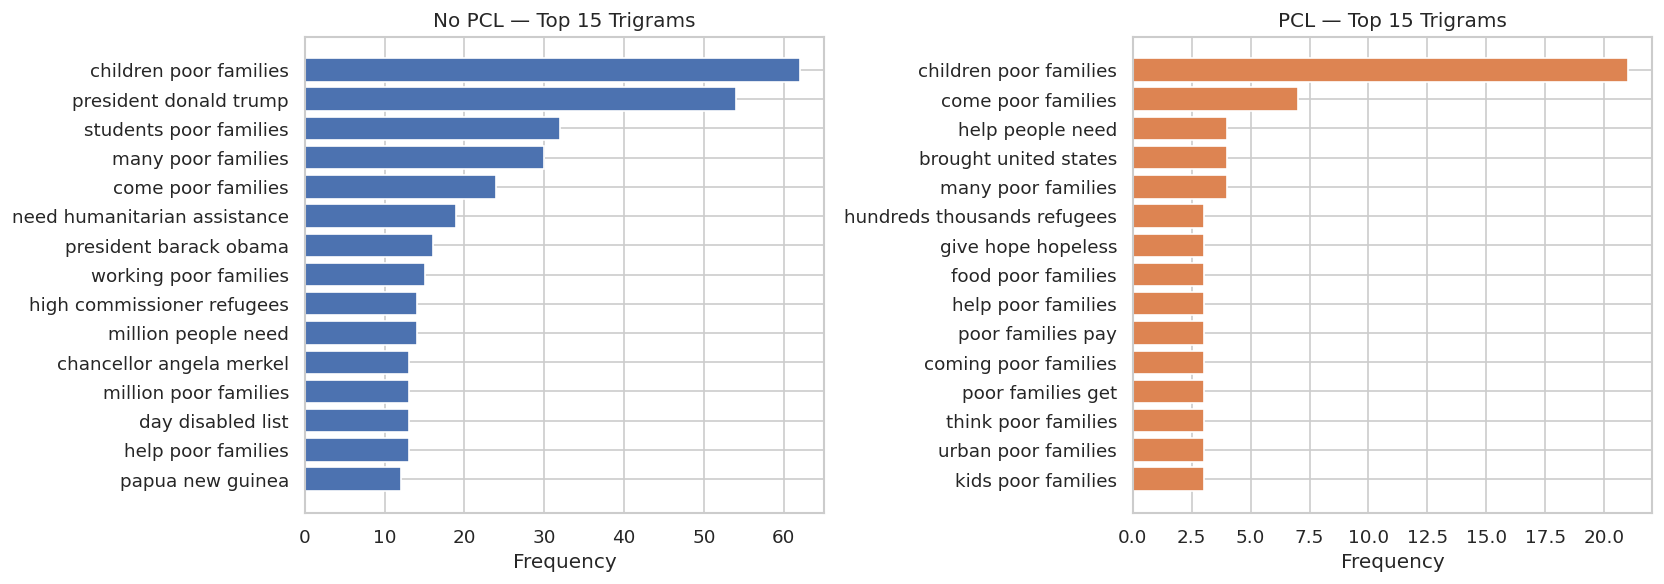

In [ ]:
# ============================================================
# Cell 9: N-gram Frequency Comparison
# ============================================================
def get_ngram_freq(token_series, n=2, top_k=20):
    """Compute the top-k most frequent n-grams from a series of token lists."""
    all_ngrams = []
    for tokens in token_series:
        all_ngrams.extend(list(ngrams(tokens, n)))
    return Counter(all_ngrams).most_common(top_k)

# Bigrams
pcl_bigrams = get_ngram_freq(pcl_tokens, n=2, top_k=20)
no_pcl_bigrams = get_ngram_freq(no_pcl_tokens, n=2, top_k=20)

# Trigrams
pcl_trigrams = get_ngram_freq(pcl_tokens, n=3, top_k=15)
no_pcl_trigrams = get_ngram_freq(no_pcl_tokens, n=3, top_k=15)

def plot_ngrams(pcl_ngrams, no_pcl_ngrams, n_label, top_k=15):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, title, color in [
        (axes[0], no_pcl_ngrams[:top_k], f'No PCL — Top {top_k} {n_label}', '#4C72B0'),
        (axes[1], pcl_ngrams[:top_k], f'PCL — Top {top_k} {n_label}', '#DD8452'),
    ]:
        labels = [' '.join(ng) for ng, _ in data]
        counts = [c for _, c in data]
        ax.barh(labels[::-1], counts[::-1], color=color, edgecolor='white')
        ax.set_xlabel('Frequency')
        ax.set_title(title)

    plt.tight_layout()
    plt.savefig(f'eda_diagrams/fig_{n_label.lower().replace("-", "")}.png', bbox_inches='tight')
    plt.show()

plot_ngrams(pcl_bigrams, no_pcl_bigrams, 'Bigrams')
plot_ngrams(pcl_trigrams, no_pcl_trigrams, 'Trigrams')

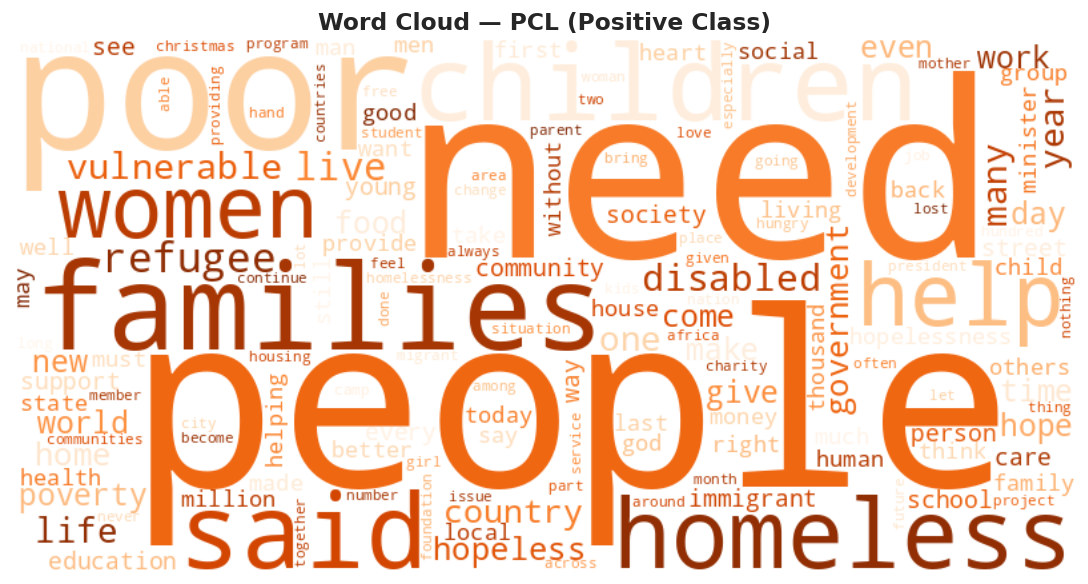

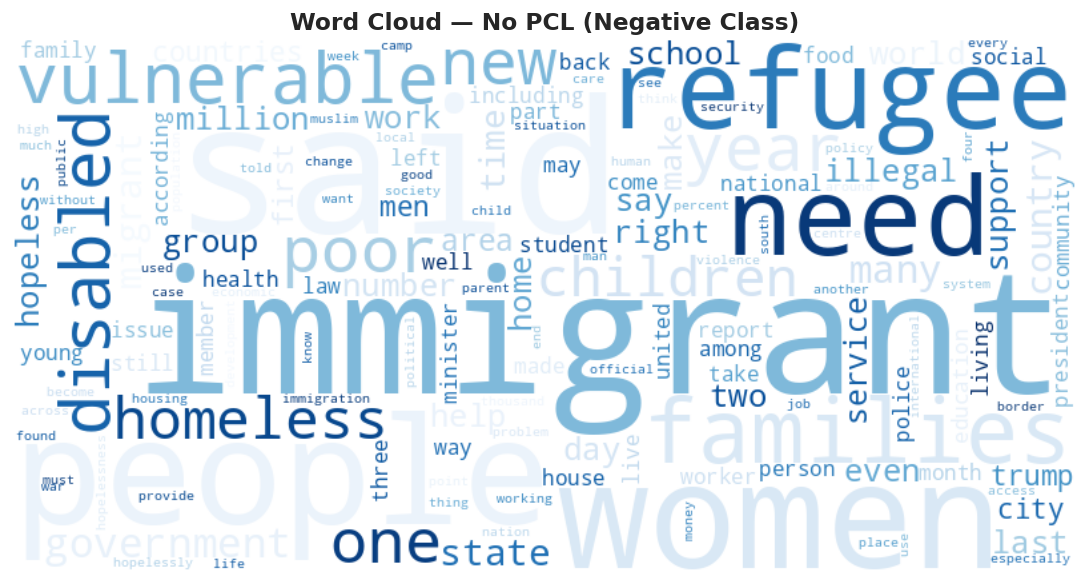

In [ ]:
# ============================================================
# Cell 10: Word Clouds per Class
# ============================================================
def make_wordcloud(token_series, title, color_map, filename):
    all_words = ' '.join([' '.join(tokens) for tokens in token_series])
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color_map,
        max_words=150,
        collocations=False
    ).generate(all_words)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"eda_diagrams/{filename}", bbox_inches='tight')
    plt.show()

make_wordcloud(pcl_tokens, 'Word Cloud — PCL (Positive Class)', 'Oranges', 'fig_wordcloud_pcl.png')
make_wordcloud(no_pcl_tokens, 'Word Cloud — No PCL (Negative Class)', 'Blues', 'fig_wordcloud_no_pcl.png')

In [12]:
# ============================================================
# Cell 11: Discriminative N-grams — Unique to PCL
# ============================================================
# Find bigrams that appear disproportionately in PCL vs No PCL
# using a simple log-ratio approach.

def ngram_counter(token_series, n=2):
    counter = Counter()
    for tokens in token_series:
        counter.update(ngrams(tokens, n))
    return counter

pcl_bg_count = ngram_counter(pcl_tokens, 2)
no_pcl_bg_count = ngram_counter(no_pcl_tokens, 2)

# Normalise by total count in each class
pcl_total = sum(pcl_bg_count.values())
no_pcl_total = sum(no_pcl_bg_count.values())

# Log-ratio: positive means more associated with PCL
all_bigrams_set = set(pcl_bg_count.keys()) | set(no_pcl_bg_count.keys())
MIN_COUNT = 10  # filter out very rare bigrams

log_ratios = []
for bg in all_bigrams_set:
    pcl_freq = pcl_bg_count.get(bg, 0)
    no_pcl_freq = no_pcl_bg_count.get(bg, 0)
    if pcl_freq + no_pcl_freq < MIN_COUNT:
        continue
    # Add smoothing
    ratio = np.log2((pcl_freq / pcl_total + 1e-8) / (no_pcl_freq / no_pcl_total + 1e-8))
    log_ratios.append((' '.join(bg), ratio, pcl_freq, no_pcl_freq))

lr_df = pd.DataFrame(log_ratios, columns=['bigram', 'log_ratio', 'pcl_count', 'no_pcl_count'])
lr_df = lr_df.sort_values('log_ratio', ascending=False)

print("Top 15 bigrams most associated with PCL:")
print(lr_df.head(15)[['bigram', 'log_ratio', 'pcl_count', 'no_pcl_count']].to_string(index=False))
print("\nTop 15 bigrams most associated with No PCL:")
print(lr_df.tail(15)[['bigram', 'log_ratio', 'pcl_count', 'no_pcl_count']].to_string(index=False))

Top 15 bigrams most associated with PCL:
           bigram  log_ratio  pcl_count  no_pcl_count
    hope hopeless  15.350372         10             0
     pope francis   3.958354          7             4
     helping hand   3.414195          6             5
      forced live   3.414195          6             5
      help people   3.288945         11            10
homeless children   3.151376          8             8
  homeless person   3.151328          7             7
       many cases   3.151263          6             6
     someone need   3.151172          5             5
       save lives   3.151172          5             5
       women need   2.981494          8             9
         long way   2.888240          5             6
        help need   2.862090         18            22
     human beings   2.665921          5             7
   brought united   2.566329          4             6

Top 15 bigrams most associated with No PCL:
                 bigram  log_ratio  pcl_count  no_

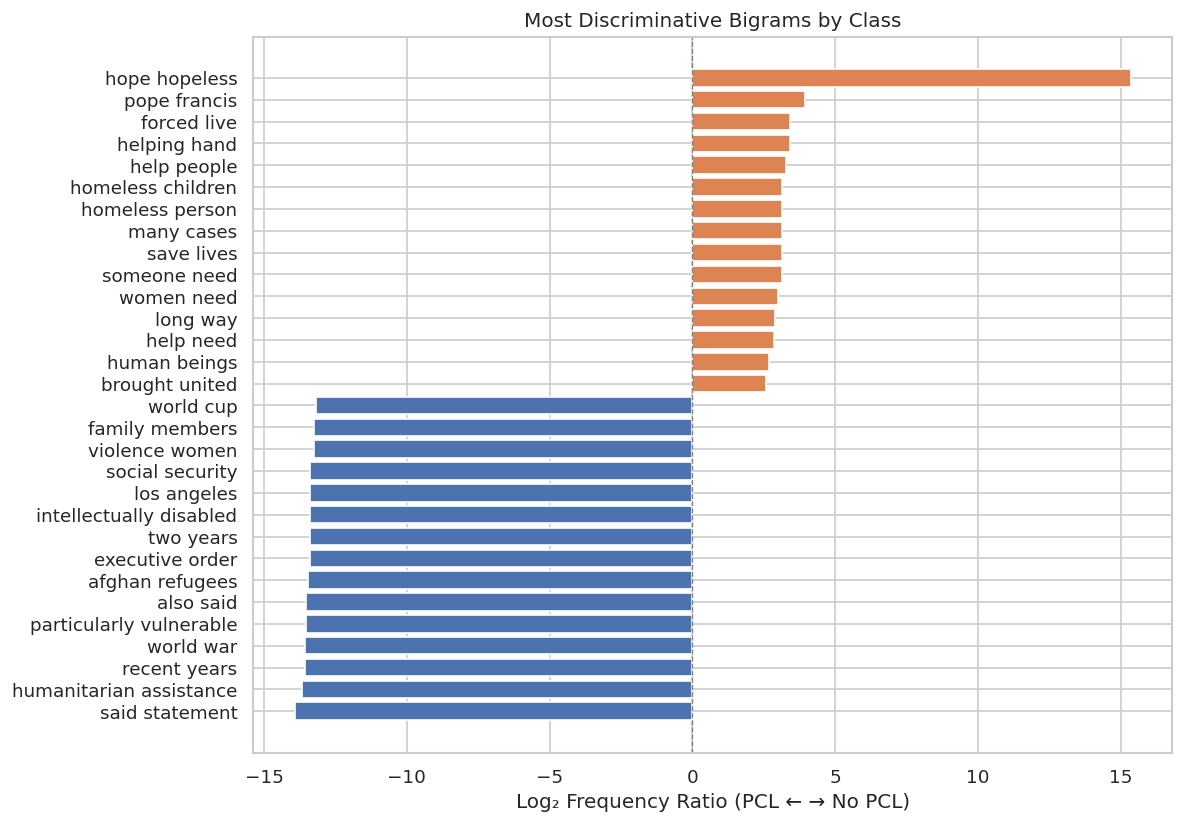

In [ ]:
# ============================================================
# Cell 12: Visualise Most Discriminative Bigrams
# ============================================================
top_pcl = lr_df.head(15)
top_no_pcl = lr_df.tail(15)
plot_df = pd.concat([top_pcl, top_no_pcl]).sort_values('log_ratio')

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#DD8452' if r > 0 else '#4C72B0' for r in plot_df['log_ratio']]
ax.barh(plot_df['bigram'], plot_df['log_ratio'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Log₂ Frequency Ratio (PCL ← → No PCL)')
ax.set_title('Most Discriminative Bigrams by Class')
plt.tight_layout()
plt.savefig('eda_diagrams/fig_discriminative_bigrams.png', bbox_inches='tight')
plt.show()

### Analysis

**Findings:**
1. **Stop-word density is moderate, not extreme:** overall stop-word density is **42.72%**. It is slightly higher in **PCL (45.32%)** than **No PCL (42.45%)**, suggesting PCL text uses more function-word-heavy phrasing.
2. **PCL bigrams with notable frequency are help/vulnerability-oriented:** among the top discriminative PCL-side phrases, higher-count examples include **"help need" (18)**, **"help people" (11)**, and **"hope hopeless" (10)**, followed by phrases like **"homeless children" (8)** and **"women need" (8)**.
3. **No-PCL bigrams show stronger high-frequency reporting patterns:** top No-PCL-side phrases include **"said statement" (33)**, **"humanitarian assistance" (28)**, **"recent years" (26)**, **"world war" (26)**, **"also said" (25)**, and **"particularly vulnerable" (25)**. These are generally news/institutional constructions rather than explicitly paternalistic framing.
4. **Frequency and ratio should be interpreted together:** some phrases can have large log-ratios with moderate counts, so ranking by association alone is not enough; absolute frequency helps identify what language is consistently present in each class.

### Impact Statement

- Feature design should prioritize **frequent class-characteristic phrases** (not only extreme ratios), because these have broader coverage in real examples.
- The high-frequency No-PCL phrases are largely report-style language, while recurring PCL phrases center more on help/need framing; models should capture this **stylistic contrast**.
- Keep log-ratio as a useful signal, but pair it with **minimum-count and top-frequency filters** to avoid over-emphasizing rare artifacts.
- These results still support contextual encoders (tone and framing matter), while frequency-aware lexical features can provide interpretable support signals.


---
## Semantic & Syntactic Exploration

This section examines structure and meaning beyond frequency statistics: POS patterns, named entities, and low-dimensional projections of term embeddings.


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/wowthecoder/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


POS analysis computed on 3,000 documents.

POS distribution (% of tokens):
       Overall (%)  No PCL (0) (%)  PCL (1) (%)
NOUN         27.74           27.90        26.32
VERB         14.34           14.30        14.77
PUNCT        12.62           12.58        12.98
ADP          11.37           11.42        10.96
DET           8.78            8.76         8.96
ADJ           7.60            7.60         7.61
PRON          4.26            4.15         5.25
ADV           3.55            3.56         3.40
PRT           3.00            2.97         3.28
CONJ          2.97            2.93         3.36
OTHER         2.08            2.08         2.12
NUM           1.68            1.75         0.99


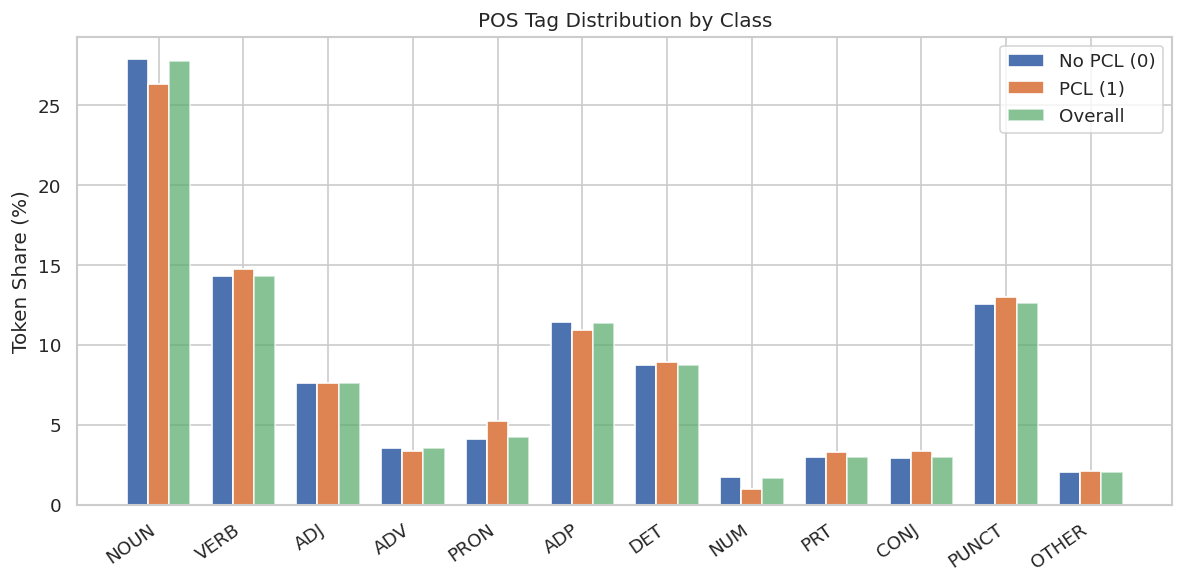

In [ ]:
# ============================================================
# Cell 13a: Part-of-Speech (POS) Tagging
# ============================================================

nltk.download("averaged_perceptron_tagger_eng")

# Set to None to run on all rows (can be slower).
POS_MAX_DOCS = 3000
pos_df = df if POS_MAX_DOCS is None else df.sample(min(POS_MAX_DOCS, len(df)), random_state=42)

def coarse_pos(tag):
    if tag.startswith('NN'): return 'NOUN'
    if tag.startswith('VB'): return 'VERB'
    if tag.startswith('JJ'): return 'ADJ'
    if tag.startswith('RB'): return 'ADV'
    if tag in ('PRP', 'PRP$', 'WP', 'WP$'): return 'PRON'
    if tag in ('IN',): return 'ADP'
    if tag in ('DT', 'PDT', 'WDT'): return 'DET'
    if tag == 'CD': return 'NUM'
    if tag in ('TO', 'RP'): return 'PRT'
    if tag in ('CC',): return 'CONJ'
    if not tag[0].isalnum(): return 'PUNCT'
    return 'OTHER'

def pos_distribution(text_series):
    from collections import Counter
    counts = Counter()
    total = 0
    for text in text_series:
        tokens = word_tokenize(str(text))
        tagged = nltk.pos_tag(tokens, lang='eng')
        for _, tag in tagged:
            counts[coarse_pos(tag)] += 1
            total += 1
    dist = pd.Series(counts, dtype=float)
    return (dist / total * 100).sort_values(ascending=False)

overall_pos = pos_distribution(pos_df['text'])
pcl_pos = pos_distribution(pos_df[pos_df['label'] == 1]['text'])
no_pcl_pos = pos_distribution(pos_df[pos_df['label'] == 0]['text'])

pos_compare = pd.concat(
    [overall_pos.rename('Overall (%)'), no_pcl_pos.rename('No PCL (0) (%)'), pcl_pos.rename('PCL (1) (%)')],
    axis=1
).fillna(0).round(2)

print(f'POS analysis computed on {len(pos_df):,} documents.')
print('\nPOS distribution (% of tokens):')
print(pos_compare.to_string())

plot_order = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'ADP', 'DET', 'NUM', 'PRT', 'CONJ', 'PUNCT', 'OTHER']
plot_df = pos_compare.reindex(plot_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df.index))
w = 0.25
ax.bar(x - w, plot_df['No PCL (0) (%)'], width=w, color='#4C72B0', label='No PCL (0)')
ax.bar(x, plot_df['PCL (1) (%)'], width=w, color='#DD8452', label='PCL (1)')
ax.bar(x + w, plot_df['Overall (%)'], width=w, color='#55A868', alpha=0.7, label='Overall')

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha='right')
ax.set_ylabel('Token Share (%)')
ax.set_title('POS Tag Distribution by Class')
ax.legend()
plt.tight_layout()
plt.savefig('eda_diagrams/fig_pos_distribution.png', bbox_inches='tight')
plt.show()


NER computed on 500 documents.
Total entities extracted: 1,204

Top 20 named entities (surface forms):
        entity  count
            US     13
         Trump     13
        Africa      9
       African      9
   New Zealand      8
         Syria      8
        Canada      7
        Syrian      7
            EU      6
         China      6
         Jesus      6
        Muslim      6
       Britain      5
      Pakistan      5
            UN      5
United Nations      5
        Europe      5
        France      5
          U.S.      5
         North      5

Entity label distribution by class (%):
              No PCL (0) %  PCL (1) %
GPE                  36.22      35.11
PERSON               31.08      35.11
ORGANIZATION         29.82      28.72
GSP                   1.26       1.06
LOCATION              1.08       0.00
FACILITY              0.54       0.00


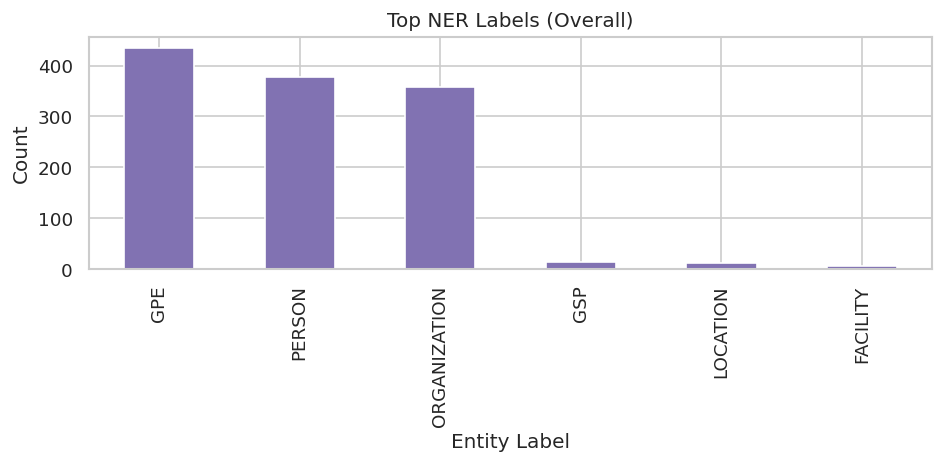

In [ ]:
# ============================================================
# Cell 13b: Named Entity Recognition (NER)
# ============================================================
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)

from nltk.tree import Tree

# Limit for runtime. Set to None for full corpus.
NER_MAX_DOCS = 500
ner_df = df if NER_MAX_DOCS is None else df.sample(min(NER_MAX_DOCS, len(df)), random_state=42).copy()

def extract_named_entities(text):
    tokens = word_tokenize(str(text))
    tagged = nltk.pos_tag(tokens)
    chunked = nltk.ne_chunk(tagged, binary=False)
    entities = []
    for chunk in chunked:
        if isinstance(chunk, Tree):
            label = chunk.label()
            name = ' '.join(token for token, _ in chunk.leaves())
            entities.append((name, label))
    return entities

ner_df['entities'] = ner_df['text'].apply(extract_named_entities)

entity_label_counts = Counter(label for ents in ner_df['entities'] for _, label in ents)
top_entities = Counter(name for ents in ner_df['entities'] for name, _ in ents).most_common(20)

def entity_label_dist(sub_df):
    c = Counter(label for ents in sub_df['entities'] for _, label in ents)
    total = sum(c.values()) if sum(c.values()) > 0 else 1
    return pd.Series({k: v / total * 100 for k, v in c.items()}).sort_values(ascending=False)

ner_no = entity_label_dist(ner_df[ner_df['label'] == 0])
ner_yes = entity_label_dist(ner_df[ner_df['label'] == 1])
ner_compare = pd.concat([ner_no.rename('No PCL (0) %'), ner_yes.rename('PCL (1) %')], axis=1).fillna(0).round(2)

print(f'NER computed on {len(ner_df):,} documents.')
print(f'Total entities extracted: {sum(entity_label_counts.values()):,}')
print('\nTop 20 named entities (surface forms):')
print(pd.DataFrame(top_entities, columns=['entity', 'count']).to_string(index=False))
print('\nEntity label distribution by class (%):')
print(ner_compare.to_string())

if len(entity_label_counts) > 0:
    label_df = pd.Series(entity_label_counts).sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(8, 4))
    label_df.plot(kind='bar', ax=ax, color='#8172B2', edgecolor='white')
    ax.set_title('Top NER Labels (Overall)')
    ax.set_ylabel('Count')
    ax.set_xlabel('Entity Label')
    plt.tight_layout()
    plt.savefig('eda_diagrams/fig_ner_labels.png', bbox_inches='tight')
    plt.show()


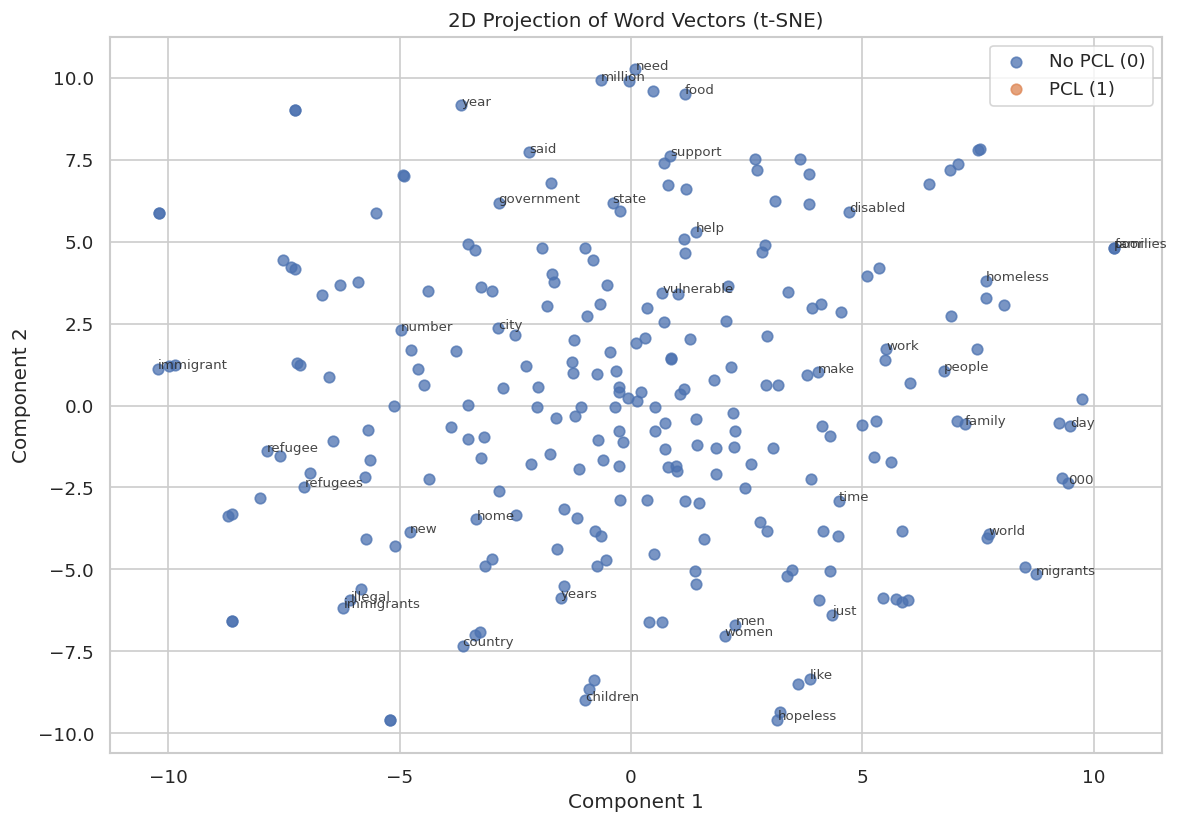

Projection method: t-SNE
Vocabulary size in vectorizer: 3,941
Terms projected: 250


In [ ]:
# ============================================================
# Cell 13c: Embedding Visualization (Shared Prep + t-SNE)
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

MIN_DF = 10
MAX_DF = 0.8
MAX_TERMS = 250
ANNOTATE_TOP = 40

vectorizer = TfidfVectorizer(stop_words='english', min_df=MIN_DF, max_df=MAX_DF)
X_all = vectorizer.fit_transform(df['text'].astype(str))  # docs x terms
terms = np.array(vectorizer.get_feature_names_out())

word_doc = X_all.T  # terms x docs
term_scores = np.asarray(word_doc.sum(axis=1)).ravel()

top_idx = np.argsort(term_scores)[-MAX_TERMS:]
selected_terms = terms[top_idx]
selected_scores = term_scores[top_idx]
W = word_doc[top_idx, :]

order = np.argsort(selected_scores)
selected_terms = selected_terms[order]
selected_scores = selected_scores[order]
W = W[order, :]

n_svd = max(2, min(50, W.shape[0] - 1, W.shape[1] - 1))
svd = TruncatedSVD(n_components=n_svd, random_state=42)
W_reduced = svd.fit_transform(W)

X_no = vectorizer.transform(df[df['label'] == 0]['text'].astype(str))
X_yes = vectorizer.transform(df[df['label'] == 1]['text'].astype(str))
no_scores = np.asarray(X_no.sum(axis=0)).ravel()[top_idx][order]
yes_scores = np.asarray(X_yes.sum(axis=0)).ravel()[top_idx][order]
dominant_class = np.where(yes_scores > no_scores, 'PCL (1)', 'No PCL (0)')

def plot_embedding_projection(coords, method, filename):
    fig, ax = plt.subplots(figsize=(10, 7))
    for cls, color in [('No PCL (0)', '#4C72B0'), ('PCL (1)', '#DD8452')]:
        m = dominant_class == cls
        ax.scatter(coords[m, 0], coords[m, 1], s=40, alpha=0.75, c=color, label=cls)

    top_annot_idx = np.argsort(selected_scores)[-ANNOTATE_TOP:]
    for i in top_annot_idx:
        ax.text(coords[i, 0], coords[i, 1], selected_terms[i], fontsize=8, alpha=0.85)

    ax.set_title(f'2D Projection of Word Vectors ({method})')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"eda_diagrams/{filename}", bbox_inches='tight')
    plt.show()

perp = min(30, max(5, (W_reduced.shape[0] - 1) // 3))
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=perp)
coords_tsne = tsne.fit_transform(W_reduced)
plot_embedding_projection(coords_tsne, 't-SNE', 'fig_embedding_projection_tsne.png')

print('Projection method: t-SNE')
print(f'Vocabulary size in vectorizer: {len(terms):,}')
print(f'Terms projected: {len(selected_terms):,}')


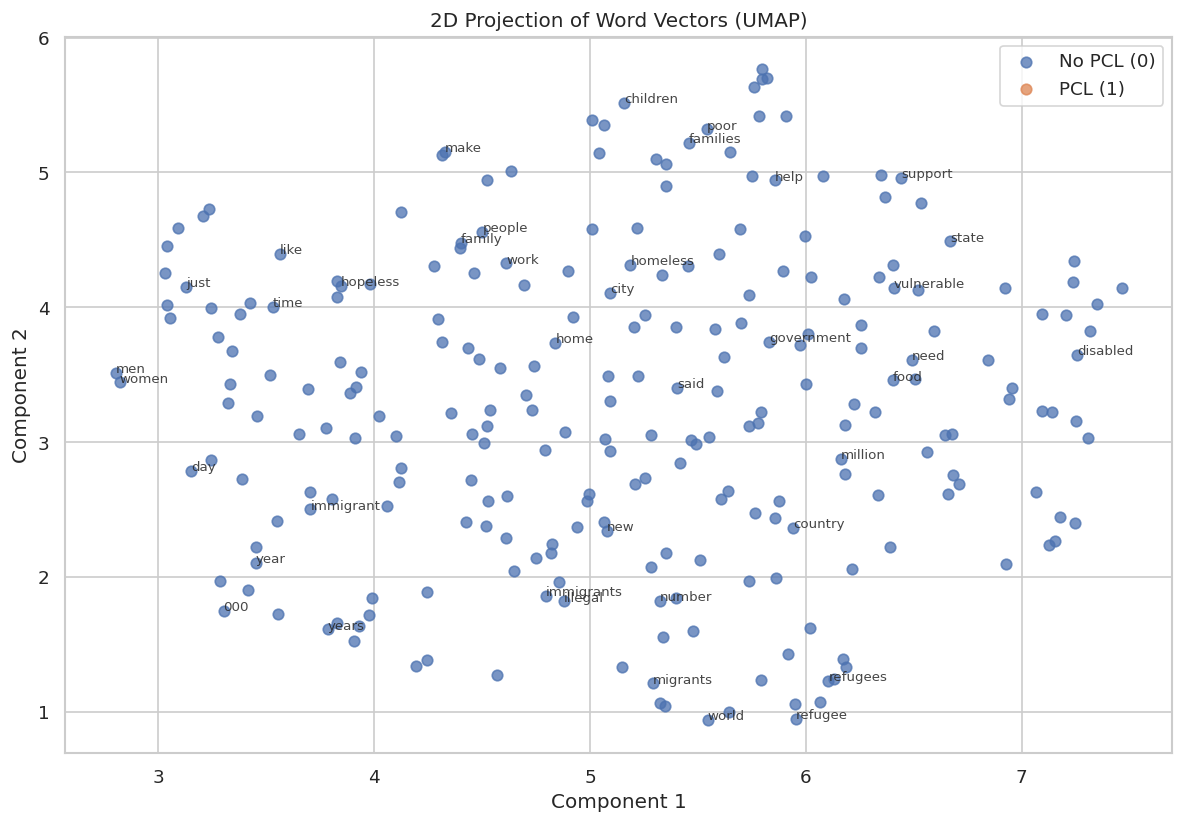

Projection method: UMAP
Vocabulary size in vectorizer: 3,941
Terms projected: 250


In [ ]:
# ============================================================
# Cell 13d: Embedding Visualization (UMAP)
# ============================================================
import umap.umap_ as umap

umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords_umap = umap_model.fit_transform(W_reduced)
plot_embedding_projection(coords_umap, 'UMAP', 'fig_embedding_projection_umap.png')

print('Projection method: UMAP')
print(f'Vocabulary size in vectorizer: {len(terms):,}')
print(f'Terms projected: {len(selected_terms):,}')


### Analysis

**Findings:**
1. **POS balance is noun-heavy, with meaningful class shifts:** nouns are the largest share overall (**27.74%**), followed by verbs (**14.34%**). PCL has slightly **fewer nouns** (26.32% vs 27.90%) but **more verbs** (14.77% vs 14.30%) and notably **more pronouns** (5.25% vs 4.15%), suggesting more person-oriented/relational framing.
2. **Named entities are dominated by places, people, and organizations:** from 500 sampled documents, NER extracted **1,204** entities. The class-wise distribution is mostly **GPE, PERSON, ORGANIZATION** for both classes, with PCL showing a higher PERSON share (35.11% vs 31.08%).
3. **Entity surface forms confirm global-news context:** top mentions include geopolitical and public-figure entities (e.g., *US, Trump, Africa, Syria, UN*), consistent with the dataset's journalistic domain.
4. **Embedding projections were generated with both methods:** both **t-SNE** and **UMAP** projected **250 terms** from a vectorizer vocabulary of **3,941**, providing complementary views of semantic neighborhoods before model training.

### Impact Statement

- The POS and NER patterns indicate the task is not just about topic keywords; it also depends on **how actors and actions are framed**. This supports contextual encoders over purely lexical baselines.
- Because PCL shows relatively higher pronoun and PERSON-entity signal, features capturing **agency and target framing** (who is being described, and with what verb structure) are likely useful.
- Use embedding projections as a **sanity-check diagnostic**: if semantically related terms cluster coherently in both t-SNE and UMAP, representation quality is reasonable before supervised training.
- Keep syntactic/semantic cues during preprocessing: aggressive normalization may remove stylistic markers that help distinguish paternalistic tone from neutral reporting.


---
## Noise & Artifact Detection

Quick checks for data quality issues (duplicates, HTML artifacts, outliers) that inform preprocessing.

In [21]:
# ============================================================
# Cell 12: Noise & Artifacts
# ============================================================
# Check for HTML artifacts
html_pattern = re.compile(r'<[^>]+>|&[a-z]+;|&amp;|&lt;|&gt;')
df['has_html'] = df['text'].astype(str).apply(lambda x: bool(html_pattern.search(x)))
print(f"Paragraphs containing HTML artifacts: {df['has_html'].sum()} ({df['has_html'].mean()*100:.1f}%)")

# Show some examples if they exist
if df['has_html'].sum() > 0:
    print("\nExample HTML artifacts:")
    for text in df[df['has_html']]['text'].head(3):
        print(f"  → {text[:150]}...")

# Check for very short paragraphs (potential noise)
short_threshold = 10  # words
short_samples = df[df['word_count'] < short_threshold]
print(f"\nParagraphs shorter than {short_threshold} words: {len(short_samples)}")
if len(short_samples) > 0:
    print("Examples:")
    for _, row in short_samples.head(5).iterrows():
        print(f"  [{row['label']}] {row['text']}")

# Duplicate text check
dup_texts = df[df.duplicated(subset='text', keep=False)]
print(f"\nDuplicate text entries: {len(dup_texts)} rows ({df.duplicated(subset='text').sum()} duplicates)")
if len(dup_texts) > 0:
    # Check if duplicates have conflicting labels
    conflicting = dup_texts.groupby('text')['label'].nunique()
    conflicting = conflicting[conflicting > 1]
    print(f"Duplicates with conflicting labels: {len(conflicting)}")

Paragraphs containing HTML artifacts: 469 (4.5%)

Example HTML artifacts:
  → Apart from Pakistan and hosts England , Bangladesh disabled cricket team will also participate in the tournament . <h> Shahid Afridi bags 11 Man of th...
  → Rizvi : There will be no joy this Eid <h> ' The citizens of this nation are becoming hopeless '...
  → Over the past 15 years , the show has handed over more than $50 million to the Mustard Seed Communities to assist with the care of more than 400 aband...

Paragraphs shorter than 10 words: 178
Examples:
  [0] Sri Lanka among most vulnerable economies that strengthens dollar
  [0] New Dar master plan to render millions homeless
  [0] The Filipino immigrant
  [1] Call to restore hope for homeless through inquiry
  [0] Syrian refugees upkeep at no cost to taxpayer

Duplicate text entries: 0 rows (0 duplicates)


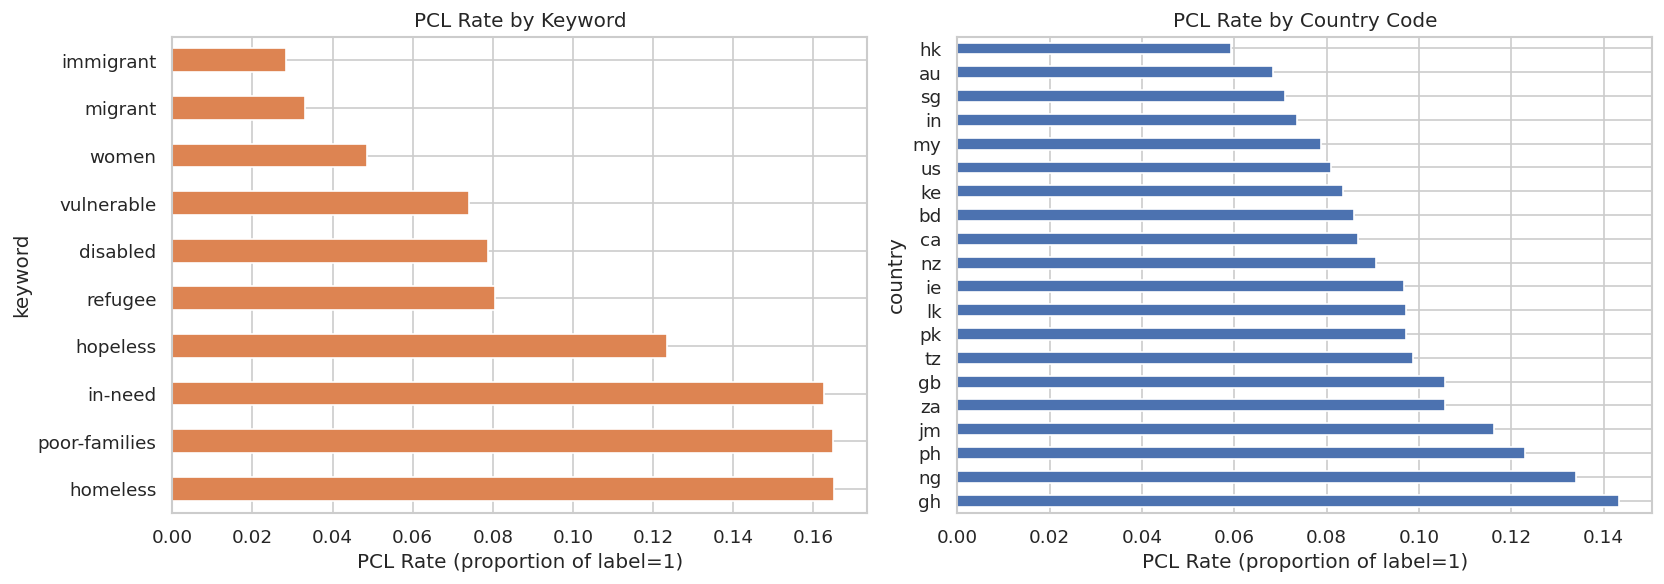

In [ ]:
# ============================================================
# Cell 13: Keyword & Country Distribution (supplementary)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Keywords
kw_pcl_rate = df.groupby('keyword')['label'].mean().sort_values(ascending=False)
kw_counts = df['keyword'].value_counts()

ax = axes[0]
kw_pcl_rate.plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
ax.set_xlabel('PCL Rate (proportion of label=1)')
ax.set_title('PCL Rate by Keyword')

# Country codes
cc_pcl_rate = df.groupby('country')['label'].mean().sort_values(ascending=False)
ax = axes[1]
cc_pcl_rate.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_xlabel('PCL Rate (proportion of label=1)')
ax.set_title('PCL Rate by Country Code')

plt.tight_layout()
plt.savefig('eda_diagrams/fig_keyword_country.png', bbox_inches='tight')
plt.show()

This shows that certain keywords and country codes have higher PCL rates,
which supports the approach of concatenating keyword and country
as additional input features to the model.